In [1]:
import sys
sys.path.append("..")  # needed to import dataloader.py

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataloader import MultiTaskBrainDataset
from torch.utils.data import DataLoader

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
class ConvBlock(torch.nn.Module):
    """Two conv layers with GroupNorm + ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            torch.nn.GroupNorm(4, out_ch),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            torch.nn.GroupNorm(4, out_ch),
            torch.nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class TinyUNet(torch.nn.Module):
    """
    Lightweight U-Net (3-level encoder, skip connections).
    Input:  (B, 1, H, W)
    Output: (B, num_classes, H, W)  - raw logits
    """
    def __init__(self, num_classes=1, base_ch=12):
        super().__init__()
        self.enc1 = ConvBlock(1,         base_ch)
        self.enc2 = ConvBlock(base_ch,   base_ch * 2)
        self.enc3 = ConvBlock(base_ch*2, base_ch * 4)
        self.pool = torch.nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base_ch*4, base_ch*8)

        self.up3  = torch.nn.ConvTranspose2d(base_ch*8, base_ch*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_ch*8, base_ch*4)
        self.up2  = torch.nn.ConvTranspose2d(base_ch*4, base_ch*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_ch*4, base_ch*2)
        self.up1  = torch.nn.ConvTranspose2d(base_ch*2, base_ch,   kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_ch*2, base_ch)

        self.head = torch.nn.Conv2d(base_ch, num_classes, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        x  = self.bottleneck(self.pool(s3))
        x  = self.dec3(torch.cat([self.up3(x), s3], dim=1))
        x  = self.dec2(torch.cat([self.up2(x), s2], dim=1))
        x  = self.dec1(torch.cat([self.up1(x), s1], dim=1))
        return self.head(x)

In [3]:
checkpoint_dir  = os.path.join("..", "results", "segmentation", "tumor_segmentation_v2.1_grant")
best_model_path = os.path.join(checkpoint_dir, "best_model.pt")

checkpoint = torch.load(best_model_path, map_location=device)

model = TinyUNet(num_classes=1, base_ch=12)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  "
      f"(val_dice = {checkpoint['val_dice']:.4f})")

C:\Users\glawl\AppData\Local\Temp\ipykernel_2380\2196694376.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)

Loaded checkpoint from epoch 100  (val_dice = 0.8548)


In [4]:
test_data = MultiTaskBrainDataset(
    os.path.join("..", "brisc2025"),
    mode="segmentation",
    train_or_test="test",
    augment=False,
    seed=42,
    new_height=256,
    new_width=256,
)

print(f"Test samples: {len(test_data)}")

PREFIX_MAP = {
    "gl": "glioma",
    "me": "meningioma",
    "pi": "pituitary",
}

def infer_tumor_type(img_path: str, mask_path) -> str:
    """Derive a human-readable tumor-type label from the sample paths."""
    if mask_path is None:
        return "no_tumor"
    fname = os.path.splitext(os.path.basename(img_path))[0]   # e.g. "Te_gl_0001"
    parts = fname.lower().split("_")
    for part in parts:
        if part in PREFIX_MAP:
            return PREFIX_MAP[part]
    return "tumor"   # fallback if naming convention doesn't match

# Build a parallel metadata list: (img_path, mask_path, tumor_type)
sample_meta = [
    (img_path, mask_path, infer_tumor_type(img_path, mask_path))
    for img_path, mask_path in test_data.samples
]

unique_types = sorted(set(m[2] for m in sample_meta))
print(f"Tumor types found: {unique_types}")
for t in unique_types:
    count = sum(1 for m in sample_meta if m[2] == t)
    print(f"  {t:<15} {count} samples")

Test samples: 1000
Tumor types found: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  glioma          254 samples
  meningioma      306 samples
  no_tumor        140 samples
  pituitary       300 samples


In [5]:
def dice_score(pred_logits: torch.Tensor, target: torch.Tensor,
               threshold: float = 0.5, eps: float = 1e-6) -> float:
    """Per-sample Dice (scalar)."""
    probs = torch.sigmoid(pred_logits)
    preds = (probs > threshold).float()
    inter = (preds * target).sum()
    union = preds.sum() + target.sum()
    return ((2.0 * inter + eps) / (union + eps)).item()


# Storage: one record per test sample
records = []   # {idx, tumor_type, dice, image_np, true_mask_np, pred_mask_np}

# Use batch_size=1 so each iteration maps to exactly one sample_meta entry
loader = DataLoader(test_data, batch_size=1, shuffle=False, num_workers=0)

with torch.no_grad():
    for idx, (img, mask) in enumerate(loader):
        img_dev  = img.to(device)
        mask_dev = mask.float().to(device)

        logits = model(img_dev)               # (1,1,256,256)
        d      = dice_score(logits, mask_dev)

        pred_bin = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()  # (256,256)
        img_np   = img.squeeze().cpu().numpy()                                     # (256,256)
        mask_np  = mask.squeeze().cpu().numpy()                                    # (256,256)

        tumor_type = str(sample_meta[idx][2])

        records.append({
            "idx":        idx,
            "tumor_type": tumor_type,
            "dice":       d,
            "image":      img_np,
            "true_mask":  mask_np,
            "pred_mask":  pred_bin,
        })

print(f"Inference complete - {len(records)} samples processed.")

overall_dice = np.mean([r["dice"] for r in records])
print(f"Overall mean test Dice: {overall_dice:.4f}")

Inference complete - 1000 samples processed.
Overall mean test Dice: 0.8504


In [9]:
from collections import defaultdict

min_or_max = min

# Group by tumor type
groups = defaultdict(list)
for r in records:
    groups[r["tumor_type"]].append(r)

# Pick the record with the highest Dice within each group
best_per_type = {}
for tumor_type, recs in sorted(groups.items()):
    best = min_or_max(recs, key=lambda r: r["dice"])
    best_per_type[tumor_type] = best
    print(f"  {tumor_type:20s}  {'worst' if min_or_max is min else 'best'} Dice = {best['dice']:.4f}  (sample idx {best['idx']})")

print(f"\n{len(best_per_type)} tumor type(s) selected for visualization.")

  glioma                worst Dice = 0.0000  (sample idx 209)
  meningioma            worst Dice = 0.2276  (sample idx 392)
  no_tumor              worst Dice = 0.0000  (sample idx 861)
  pituitary             worst Dice = 0.0000  (sample idx 741)

4 tumor type(s) selected for visualization.


C:\Users\glawl\AppData\Local\Temp\ipykernel_2380\2189481820.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


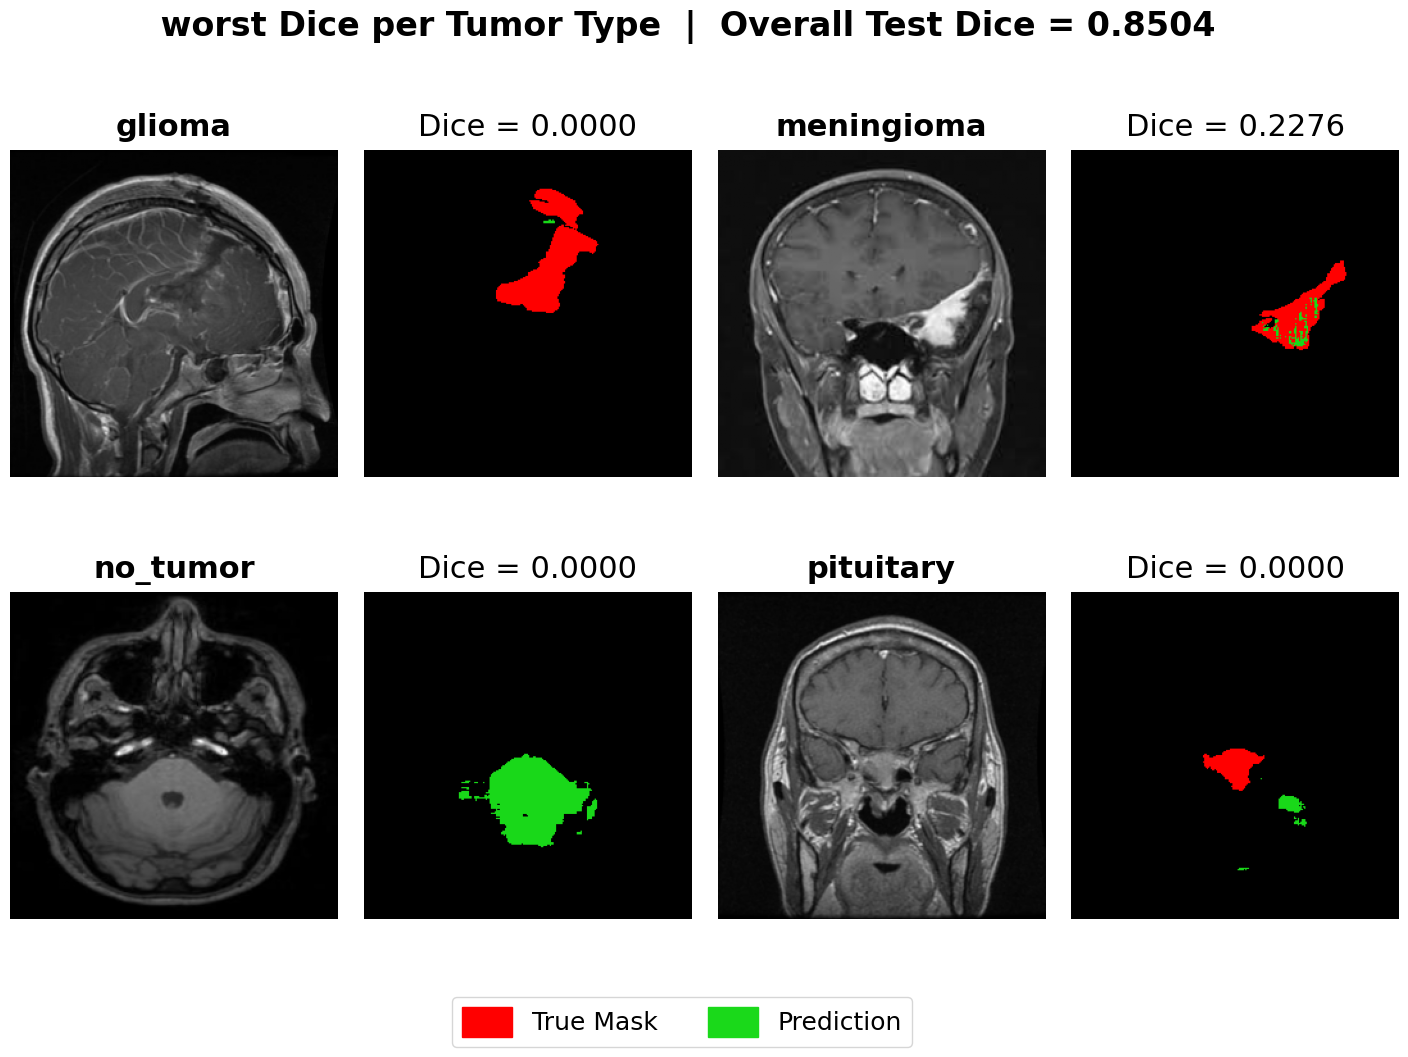

In [10]:
def normalize_for_display(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)


fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 10),
    gridspec_kw={"wspace": 0.06, "hspace": 0.35},
)

sorted_items = sorted(best_per_type.items())

for i, (tumor_type, rec) in enumerate(sorted_items):
    row, col = divmod(i, 2)
    ax_mri  = axes[row, col * 2]
    ax_mask = axes[row, col * 2 + 1]

    true_mask = rec["true_mask"]
    pred_mask = rec["pred_mask"]

    # MRI
    ax_mri.imshow(normalize_for_display(rec["image"]), cmap="gray", vmin=0, vmax=1)
    ax_mri.set_title(f"{tumor_type}", fontsize=22, fontweight="bold", pad=10)

    # Mask + prediction overlay
    rgb = np.zeros((*true_mask.shape, 3), dtype=np.float32)
    rgb[:, :, 0] = true_mask  # red channel only
    rgb[pred_mask == 1] = [0.10, 0.85, 0.10]  # green prediction on top
    ax_mask.imshow(rgb, vmin=0, vmax=1)
    ax_mask.set_title(f"Dice = {rec['dice']:.4f}", fontsize=22, pad=10)

    for ax in (ax_mri, ax_mask):
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color="red",            label="True Mask"),
    mpatches.Patch(color=(0.10, 0.85, 0.10), label="Prediction"),
]
fig.legend(
    handles=legend_patches, loc="lower center", ncol=2,
    fontsize=18, frameon=True, bbox_to_anchor=(0.5, -0.03),
    handlelength=2, handleheight=1.5,
)

fig.suptitle(
    f" {'worst' if min_or_max is min else 'best'} Dice per Tumor Type  |  Overall Test Dice = {overall_dice:.4f}",
    fontsize=24, fontweight="bold", y=1.02,
)

plt.tight_layout()
plt.savefig("best_per_tumor_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print(f"{'Tumor Type':<22} {'N':>5} {'Mean Dice':>10} {'Std Dice':>10} {'Min':>8} {'Max':>8}")
print("-" * 68)
for tumor_type, recs in sorted(groups.items()):
    dices = [r["dice"] for r in recs]
    print(
        f"{tumor_type:<22} {len(dices):>5} "
        f"{np.mean(dices):>10.4f} {np.std(dices):>10.4f} "
        f"{np.min(dices):>8.4f} {np.max(dices):>8.4f}"
    )
print("-" * 68)
all_dices = [r["dice"] for r in records]
print(
    f"{'OVERALL':<22} {len(all_dices):>5} "
    f"{np.mean(all_dices):>10.4f} {np.std(all_dices):>10.4f} "
    f"{np.min(all_dices):>8.4f} {np.max(all_dices):>8.4f}"
)

Tumor Type                 N  Mean Dice   Std Dice      Min      Max
--------------------------------------------------------------------
glioma                   254     0.7166     0.2831   0.0000   0.9789
meningioma               306     0.9264     0.0876   0.2276   0.9891
no_tumor                 140     0.9571     0.2025   0.0000   1.0000
pituitary                300     0.8362     0.1865   0.0000   0.9878
--------------------------------------------------------------------
OVERALL                 1000     0.8504     0.2165   0.0000   1.0000
